# ES algorithms and 10 benchmark functions
* (1,1) random
* (1+1) with 1/5 success rule
* (mu+lamda) with 1/5 success rule
* (mu+lamda) with 1/5 success rule + variance adaptation

*CJ Chung, Nov. 2025-*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### 10 optimization functions

In [ ]:
# Function definitions
def sphere(x):
    """Unimodal, convex function"""
    return np.sum(x**2)

def rosenbrock(x):
    """Unimodal with curved valley"""
    result = 0
    for i in range(len(x)-1):
        result += 100 * (x[i+1] - x[i]**2)**2 + (1 - x[i])**2
    return result

def rastrigin(x):
    """Highly multimodal"""
    n = len(x)
    return 10 * n + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def ackley(x):
    """Many local minima, nearly flat outer region"""
    n = len(x)
    a, b, c = 20, 0.2, 2 * np.pi
    sum1 = np.sum(x**2)
    sum2 = np.sum(np.cos(c * x))
    term1 = -a * np.exp(-b * np.sqrt(sum1 / n))
    term2 = -np.exp(sum2 / n)
    return term1 + term2 + a + np.e

def griewank(x):
    """Multimodal with product term"""
    n = len(x)
    sum_part = np.sum(x**2) / 4000
    prod_part = np.prod(np.cos(x / np.sqrt(np.arange(1, n + 1))))
    return 1 + sum_part - prod_part

def schwefel(x):
    """Multimodal with global optimum near boundary"""
    n = len(x)
    return 418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x))))

def lunacek_bi_rastrigin(x):
    """Deceptive double-funnel function"""
    n = len(x)
    mu0 = 2.5
    s = 1 - 1 / (2 * np.sqrt(n + 20) - 8.2)
    mu1 = -np.sqrt((mu0**2 - 1) / s)

    x_shifted1 = 2 * x
    x_shifted2 = x - mu0

    sum1 = np.sum((x_shifted1 - mu0)**2)
    sum2 = np.sum((x_shifted2 - mu1)**2)

    min_sum = min(sum1, n * mu0**2 + sum2)
    rastrigin_part = 10 * (n - np.sum(np.cos(2 * np.pi * x_shifted2)))

    return min_sum + rastrigin_part

def levy(x):
    """Highly multimodal with rugged landscape"""
    w = 1 + (x - 1) / 4
    term1 = np.sin(np.pi * w[0])**2
    term2 = np.sum((w[:-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:-1] + 1)**2))
    term3 = (w[-1] - 1)**2 * (1 + np.sin(2 * np.pi * w[-1])**2)
    return term1 + term2 + term3

def zakharov(x):
    """Unimodal but with interactions between variables"""
    n = len(x)
    sum1 = np.sum(x**2)
    sum2 = np.sum(0.5 * np.arange(1, n + 1) * x)
    return sum1 + sum2**2 + sum2**4

def hybrid_composition(x):
    """Composite function combining multiple functions"""
    n = len(x)
    if n >= 3:
        part1 = sphere(x[:n//3])
        part2 = rastrigin(x[n//3:2*n//3])
        part3 = rosenbrock(x[2*n//3:])
    else:
        part1 = sphere(x)
        part2 = rastrigin(x)
        part3 = rosenbrock(x)

    return 0.4 * part1 + 0.4 * part2 + 0.2 * part3

# all functions with their ranges and acceptable global fitness, f*(X)
functions = [
  ('Sphere', sphere, [-5.12, 5.12], 1e-5),           # Easy - should find near-optimal
  ('Rosenbrock', rosenbrock, [-2.048, 2.048], 1e-1), # Medium - curved valley makes exact optimum hard
  ('Rastrigin', rastrigin, [-5.12, 5.12], 1e0),      # Hard - many local optima
  ('Ackley', ackley, [-32.768, 32.768], 1e-1),       # Medium - many local optima but well-structured
  ('Griewank', griewank, [-600, 600], 1e-1),         # Medium - regular local optima pattern
  ('Schwefel', schwefel, [-500, 500], 1e1),          # Very hard - deceptive landscape
  ('Lunacek BiRstrgn', lunacek_bi_rastrigin, [-5.12, 5.12], 1e0), # Hard - deceptive double funnel
  ('Levy', levy, [-10, 10], 1e-1),                   # Medium - rugged but manageable
  ('Zakharov', zakharov, [-5, 5], 1e-5),             # Easy - unimodal with interactions
  ('Hybrid Composition', hybrid_composition, [-5, 5], 1e0)        # Hard - mixed characteristics
]

In [ ]:
def clip_to_bounds(x, bounds):
    """Clip solution to valid search range"""
    return np.clip(x, bounds[0], bounds[1])

### A1. ES(1,1) random search

In [ ]:
np.random.uniform(-1, 1, 2)

array([-0.11717013, -0.57507546])

In [ ]:
def random_search(objective_func, dim, max_evaluations=10000, bounds=[-5, 5]):
    """
    Simple Random Search algorithm with boundary handling.
    No explicit selection or mutation adaptation.
    """
    # Initialize the first solution randomly within bounds
    current_solution = np.random.uniform(bounds[0], bounds[1], dim)

    # Evaluate the first solution
    current_fitness = objective_func(current_solution)

    best_solution = current_solution.copy()
    best_fitness = current_fitness
    fitness_history = [current_fitness]

    evaluations = 1

    while evaluations < max_evaluations:
        # Generate a new random solution within bounds
        new_solution = np.random.uniform(bounds[0], bounds[1], dim)

        # Evaluate the new solution
        new_fitness = objective_func(new_solution)
        evaluations += 1

        # Update best solution if the new one is better
        if new_fitness < best_fitness:
            best_solution = new_solution.copy()
            best_fitness = new_fitness

        fitness_history.append(best_fitness)

    return best_solution, best_fitness, fitness_history

### A2. ES(1+1) with 1/5

In [ ]:
# Python test to generate a child using linear algebra Numpy style without using for loop
parent = np.array([0, 0, 0])
child = parent + np.random.normal(0, 1, 3) # See below using for loop
print(child)

child2 = np.zeros(3)
for i in range(len(parent)):
  child2[i] = parent[i] + np.random.normal(0, 1)
print(child2)

[-1.0724309  -0.95638684  0.92026631]
[ 0.83560615 -0.16971577 -1.0661368 ]


In [ ]:
def one_plus_one_es_one_fifth_rule(objective_func, dim, max_evaluations=10000, sigma=1.0,
                                  adaptation_interval=50, target_success_rate=0.2, bounds=[-5, 5]):
    """
    (1+1)-Evolution Strategy with 1/5 success rule and boundary handling
    Scales initial sigma and adaptation based on bounds
    """
    # Initialize parent within bounds
    parent = np.random.uniform(bounds[0], bounds[1], dim)

    # Scale initial sigma by the range of the bounds
    range_width = bounds[1] - bounds[0]
    sigma = range_width * 0.1 # Initialize sigma as 10% of the range width (arbitrary scaling factor, can be tuned)


    # Evaluate parent
    parent_fitness = objective_func(parent)

    best_solution = parent.copy()
    best_fitness = parent_fitness
    fitness_history = [parent_fitness]

    evaluations = 1
    success_count = 0  # Initialize success_count
    adaptation_counter = 0 # Initialize adaptation_counter


    while evaluations < max_evaluations:
        # Generate offspring by mutation
        offspring = parent + np.random.normal(0, sigma, dim)

        # Apply boundary constraints
        offspring = clip_to_bounds(offspring, bounds)

        # Evaluate offspring
        offspring_fitness = objective_func(offspring)
        evaluations += 1
        adaptation_counter += 1

        # Selection: (1+1) - keep the better one
        if offspring_fitness < parent_fitness:
            parent = offspring
            parent_fitness = offspring_fitness
            success_count += 1

        # 1/5 rule adaptation
        if adaptation_counter >= adaptation_interval: # WINDOW SIZE
            success_rate = success_count / adaptation_interval

            if success_rate > target_success_rate: # 20%
                # Too many successes - increase step size
                sigma = sigma * 1.1
            else:
                # Too few successes - decrease step size
                sigma = sigma * 0.9 # 0.82 used before

            # Keep sigma within reasonable bounds relative to the range
            # Ensure sigma doesn't become excessively large or small
            sigma = max(range_width * 1e-6, min(range_width, sigma)) # Example bounds relative to range

            # Reset counters
            success_count = 0
            adaptation_counter = 0

        # Update best solution
        current_best_fitness = parent_fitness # Best fitness of the *current* parent
        if current_best_fitness < best_fitness:
             best_solution = parent.copy()
             best_fitness = current_best_fitness

        fitness_history.append(best_fitness) # fitness_history[-1] has the best fitness for the run
    #<--- end of while for generations
    return best_solution, best_fitness, fitness_history

### A3. ES(mu+lamda) with 1/5

In [ ]:
# list comprehension test
p = [np.random.uniform(-1, 1, 2) for _ in range(3)] # 3 individuals in the population
print(p)

[array([-0.252228  , -0.85618795]), array([-0.22978483, -0.94184026]), array([-0.63749443,  0.38053372])]


In [ ]:
# to test zip
names = ["Rumi", "Mira", "Zoey"]
ages = [26, 28, 22]
zipped = list(zip(names, ages))
print(zipped)
# to test key param for sort and lamda func
# The key parameter expects a function that takes a single argument (an element from the iterable) and returns a value.
# This returned value is then used for comparison during the sorting process.
# lambda arguments: expression, where arguments are the input(s) to the function and
# expression is the value to be returned.
zipped.sort(key=lambda x: x[1])
print(zipped)

[('Rumi', 26), ('Mira', 28), ('Zoey', 22)]
[('Zoey', 22), ('Rumi', 26), ('Mira', 28)]


In [ ]:
def mu_plus_lambda_es_one_fifth_rule(objective_func, dim, max_evaluations=10000,
                                   mu=5, lambda_=20, sigma=1.0,
                                   adaptation_interval=50, target_success_rate=0.2, bounds=[-5, 5]):
    # why "lambda_"? "lambda" is a Python keywork!

    """
    (μ+λ)-Evolution Strategy with 1/5 success rule
    μ: parent population size
    λ: offspring population size
    Scales initial sigma and adaptation based on bounds
    """
    # Initialize parent population within bounds
    population = [np.random.uniform(bounds[0], bounds[1], dim) for _ in range(mu)]

    # Scale initial sigma by the range of the bounds
    range_width = bounds[1] - bounds[0]
    sigma = range_width * 0.1 # Initialize sigma as 10% of the range width (arbitrary scaling factor, can be tuned)


    # Evaluate initial population
    fitness_values = [objective_func(ind) for ind in population]
    evaluations = mu

    # Create list of (individual, fitness) tuples
    population_with_fitness = list(zip(population, fitness_values))

    # Sort by fitness (minimization)
    population_with_fitness.sort(key=lambda x: x[1])

    best_solution = population_with_fitness[0][0].copy()
    best_fitness = population_with_fitness[0][1]
    fitness_history = [best_fitness]

    success_count = 0 # Initialize success_count
    adaptation_counter = 0 # Initialize adaptation_counter

    while evaluations < max_evaluations:
        # Generate λ offspring
        offspring = []
        for _ in range(lambda_):
            # Select random parent (tournament selection could be used here)
            parent_idx = np.random.randint(mu)
            parent = population_with_fitness[parent_idx][0]

            # Mutate
            child = parent + np.random.normal(0, sigma, dim)
            child = clip_to_bounds(child, bounds)
            offspring.append(child)

        # Evaluate offspring
        offspring_fitness = [objective_func(ind) for ind in offspring]
        evaluations += lambda_
        adaptation_counter += lambda_

        # Combine parents and offspring
        combined = population_with_fitness + list(zip(offspring, offspring_fitness))

        # Sort by fitness and select best μ individuals
        combined.sort(key=lambda x: x[1])
        population_with_fitness = combined[:mu]

        # Count successes (offspring that are better than their parent)
        # For simplicity, we count any offspring that made it into the new population
        new_population_individuals = [ind for ind, _ in population_with_fitness]
        success_count += sum(1 for ind in offspring if any(np.array_equal(ind, pop_ind) for pop_ind in new_population_individuals))

        # 1/5 rule adaptation
        if adaptation_counter >= adaptation_interval:
            success_rate = success_count / adaptation_interval

            if success_rate > target_success_rate:
                # Too many successes - increase step size
                sigma = sigma * 1.1
            else:
                # Too few successes - decrease step size
                sigma = sigma * 0.9

            # Keep sigma within reasonable bounds relative to the range
            # Ensure sigma doesn't become excessively large or small
            sigma = max(range_width * 1e-6, min(range_width, sigma)) # Example bounds relative to range

            # Reset counters
            success_count = 0
            adaptation_counter = 0

        # Update best solution
        current_best_fitness = population_with_fitness[0][1]
        if current_best_fitness < best_fitness:
            best_solution = population_with_fitness[0][0].copy()
            best_fitness = current_best_fitness

        fitness_history.append(best_fitness)
    # <---- end of while for evaluations (generations)
    return best_solution, best_fitness, fitness_history

### A4. ES(mu+lamda) with 1/5 + variance adaptation

In [ ]:
def mu_plus_lambda_es_variance_adaptation(objective_func, dim, max_evaluations=10000,
                                         mu=5, lambda_=20, initial_sigma=1.0,
                                         adaptation_interval=50, target_success_rate=0.2, bounds=[-5, 5]):
    """
    (μ+λ)-Evolution Strategy with 1/5 success rule and variance adaptation per variable
    Adapts a sigma vector based on offspring variance and overall success rate.
    """
    # Initialize parent population within bounds
    population = [np.random.uniform(bounds[0], bounds[1], dim) for _ in range(mu)]

    # Initialize sigma vector
    # Scale initial sigma by the range of the bounds for each dimension
    range_width = bounds[1] - bounds[0]
    sigma = np.ones(dim) * (range_width * 0.1) # Initialize sigma for each dimension


    # Evaluate initial population
    fitness_values = [objective_func(ind) for ind in population]
    evaluations = mu # number of evaluations done initially

    # Create list of (individual, fitness) tuples
    population_with_fitness = list(zip(population, fitness_values))

    # Sort by fitness (minimization, ascending order)
    population_with_fitness.sort(key=lambda x: x[1])

    best_solution = population_with_fitness[0][0].copy()
    best_fitness = population_with_fitness[0][1]
    fitness_history = [best_fitness]

    success_count = 0
    adaptation_counter = 0

    while evaluations < max_evaluations:
        # Generate λ offspring
        offspring = []
        for _ in range(lambda_):
            # Select random parent (tournament selection could be used here)
            parent_idx = np.random.randint(mu)
            parent = population_with_fitness[parent_idx][0]

            # Mutate using the sigma vector (independent mutation for each dimension)
            mutation = np.random.normal(0, sigma, dim)
            child = parent + mutation
            child = clip_to_bounds(child, bounds)
            offspring.append(child)

        # Evaluate offspring
        offspring_fitness = [objective_func(ind) for ind in offspring]
        evaluations += lambda_
        adaptation_counter += lambda_

        # Combine parents and offspring
        combined = population_with_fitness + list(zip(offspring, offspring_fitness))

        # Sort by fitness and select best μ individuals
        combined.sort(key=lambda x: x[1])
        population_with_fitness = combined[:mu]

        # Count successes (offspring that are better than their parent and made it into the new population)
        new_population_individuals = np.array([ind for ind, _ in population_with_fitness])
        # Check if new_population_individuals is not empty before calculating success count
        if new_population_individuals.size > 0:
             success_count += sum(1 for ind in offspring if any(np.array_equal(ind, pop_ind) for pop_ind in new_population_individuals))

        # Variance Adaptation and 1/5 Rule
        if adaptation_counter >= adaptation_interval:
             if offspring: # Ensure offspring list is not empty
                 # Calculate variance of offspring for each dimension
                 offspring_array = np.array(offspring)
                 variance_per_dimension = np.var(offspring_array, axis=0) # to calculate the variance of array elements

                 # Ensure no division by zero or extremely small variances
                 variance_per_dimension = np.maximum(variance_per_dimension, 1e-10) # Add a small epsilon

                 # Calculate overall success rate
                 success_rate = success_count / adaptation_interval

                 # Adapt sigma vector based on 1/5 rule signal and variance
                 # If success rate is high, increase sigmas; if low, decrease.
                 # Scale the change for each dimension based on its variance.
                 # This is a simplified approach; more advanced methods exist. <==== Room for improvement!!!
                 if success_rate > target_success_rate:
                     sigma = sigma * (1.1 + 0.1 * (variance_per_dimension / np.mean(variance_per_dimension))) # Increase more for higher variance
                 else:
                     sigma = sigma * (0.9 - 0.1 * (variance_per_dimension / np.mean(variance_per_dimension))) # Decrease more for lower variance

                 # Keep sigma within reasonable bounds relative to the range
                 sigma = np.maximum(sigma, range_width * 1e-6) # Ensure minimum step size
                 sigma = np.minimum(sigma, range_width)      # Ensure maximum step size

             # Reset counters
             success_count = 0
             adaptation_counter = 0

        # Update best solution
        current_best_fitness = population_with_fitness[0][1]
        if current_best_fitness < best_fitness:
            best_solution = population_with_fitness[0][0].copy()
            best_fitness = current_best_fitness

        fitness_history.append(best_fitness)
    # <------------ end of while
    return best_solution, best_fitness, fitness_history

### Evaluate all algorithms on **a single function**

In [ ]:
def evaluate_single_function(func_name, objective_func, bounds, dim, max_evaluations, runs):
    """Evaluate all three ES variants and Random Search on a single function with proper bounds"""
    print(f"Evaluating {func_name} (range: [{bounds[0]}, {bounds[1]}])...")

    results_random =                  {'fitness': [], 'convergence': []}
    results_one_fifth =               {'fitness': [], 'convergence': []}
    results_mu_plus_lambda =          {'fitness': [], 'convergence': []}
    results_mu_plus_lambda_variance = {'fitness': [], 'convergence': []}


    for run in range(runs):
        # Random Search
        solution_random, fitness_random, convergence_random = random_search(
             objective_func, dim, max_evaluations, bounds=bounds
        )
        results_random['fitness'].append(fitness_random)
        results_random['convergence'].append(convergence_random)

        # 1/5 rule ES
        solution_1fifth, fitness_1fifth, convergence_1fifth = one_plus_one_es_one_fifth_rule(
            objective_func, dim, max_evaluations, bounds=bounds
        )
        results_one_fifth['fitness'].append(fitness_1fifth)
        results_one_fifth['convergence'].append(convergence_1fifth)

        # (μ+λ)-ES with 1/5 rule
        solution_mu_lambda, fitness_mu_lambda, convergence_mu_lambda = mu_plus_lambda_es_one_fifth_rule(
            objective_func, dim, max_evaluations, mu=5, lambda_=15, bounds=bounds
        )
        results_mu_plus_lambda['fitness'].append(fitness_mu_lambda)
        results_mu_plus_lambda['convergence'].append(convergence_mu_lambda)

        # (μ+λ)-ES with Variance Adaptation
        solution_mu_lambda_variance, fitness_mu_lambda_variance, convergence_mu_lambda_variance = mu_plus_lambda_es_variance_adaptation(
            objective_func, dim, max_evaluations, mu=5, lambda_=15, bounds=bounds
        )
        results_mu_plus_lambda_variance['fitness'].append(fitness_mu_lambda_variance)
        results_mu_plus_lambda_variance['convergence'].append(convergence_mu_lambda_variance)


        print(f"  Run {run+1}: Random = {fitness_random:.6e}, 1/5 Rule = {fitness_1fifth:.6e}, (μ+λ)-ES = {fitness_mu_lambda:.6e}, (μ+λ)-ES Vari = {fitness_mu_lambda_variance:.6e}")


    # Calculate statistics for Random Search
    random_stats = {
        'best': np.min(results_random['fitness']),
        'worst': np.max(results_random['fitness']),
        'mean': np.mean(results_random['fitness']),
        'std': np.std(results_random['fitness']),
        'convergence': results_random['convergence'] # contains fitness history of 'runs'
    }

    # Calculate statistics for 1/5 rule ES
    one_fifth_stats = {
        'best': np.min(results_one_fifth['fitness']),
        'worst': np.max(results_one_fifth['fitness']),
        'mean': np.mean(results_one_fifth['fitness']),
        'std': np.std(results_one_fifth['fitness']),
        'convergence': results_one_fifth['convergence']
    }

    # Calculate statistics for (μ+λ)-ES
    mu_plus_lambda_stats = {
        'best': np.min(results_mu_plus_lambda['fitness']),
        'worst': np.max(results_mu_plus_lambda['fitness']),
        'mean': np.mean(results_mu_plus_lambda['fitness']),
        'std': np.std(results_mu_plus_lambda['fitness']),
        'convergence': results_mu_plus_lambda['convergence']
    }

    # Calculate statistics for (μ+λ)-ES with Variance Adaptation
    mu_plus_lambda_variance_stats = {
        'best': np.min(results_mu_plus_lambda_variance['fitness']),
        'worst': np.max(results_mu_plus_lambda_variance['fitness']),
        'mean': np.mean(results_mu_plus_lambda_variance['fitness']),
        'std': np.std(results_mu_plus_lambda_variance['fitness']),
        'convergence': results_mu_plus_lambda_variance['convergence']
    }

    print(f"  Random Search: Mean = {random_stats['mean']:.6e} ± {random_stats['std']:.3e} std")
    print(f"  1/5 Rule ES:   Mean = {one_fifth_stats['mean']:.6e} ± {one_fifth_stats['std']:.3e} std")
    print(f"  (μ+λ)-ES:      Mean = {mu_plus_lambda_stats['mean']:.6e} ± {mu_plus_lambda_stats['std']:.3e} std")
    print(f"  (μ+λ)-ES Vari: Mean = {mu_plus_lambda_variance_stats['mean']:.6e} ± {mu_plus_lambda_variance_stats['std']:.3e} std")

    # Return updated stats
    return random_stats, one_fifth_stats, mu_plus_lambda_stats, mu_plus_lambda_variance_stats

### Evaluate all algos on **all functions**

In [ ]:
def evaluate_all_functions(dim=10, max_evaluations=5000, runs=5):
    """Evaluate all ES variants and Random Search on all 10 benchmark functions with proper ranges"""

    results_random = {}
    results_one_fifth = {}
    results_mu_plus_lambda = {}
    results_mu_plus_lambda_variance = {} # Added results for variance adaptation ES

    for func_name, objective_func, bounds, thr in functions:
        # Updated call to evaluate_single_function
        random_stats, one_fifth_stats, mu_plus_lambda_stats, mu_plus_lambda_variance_stats = evaluate_single_function(
            func_name, objective_func, bounds, dim, max_evaluations, runs
        )
        results_random[func_name] = random_stats
        results_one_fifth[func_name] = one_fifth_stats
        results_mu_plus_lambda[func_name] = mu_plus_lambda_stats
        results_mu_plus_lambda_variance[func_name] = mu_plus_lambda_variance_stats # Added assignment for variance adaptation ES
    # Return updated results dictionaries
    return results_random, results_one_fifth, results_mu_plus_lambda, results_mu_plus_lambda_variance, functions

### Output and Visulization

In [ ]:
def plot_comparison_results(results_random, results_one_fifth, results_mu_plus_lambda, results_mu_plus_lambda_variance, functions):
    """Create comprehensive visualization comparing all four algorithms"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    function_names = [func[0] for func in functions]

    # ---- Plot 1: Final performance comparison
    means_random = [results_random[name]['mean'] for name in function_names]
    means_one_fifth = [results_one_fifth[name]['mean'] for name in function_names]
    means_mu_plus_lambda = [results_mu_plus_lambda[name]['mean'] for name in function_names]
    means_mu_plus_lambda_variance = [results_mu_plus_lambda_variance[name]['mean'] for name in function_names] # Added means for variance adaptation ES


    # Adjusted x_pos and width for 4 bars
    x_pos = np.arange(len(function_names))
    width = 0.18

    axes[0].bar(x_pos - 1.5*width, means_random, width, label='Random Search', alpha=0.7, color='purple')
    axes[0].bar(x_pos - 0.5*width, means_one_fifth, width, label='1/5 Rule ES', alpha=0.7, color='red') # Adjusted position
    axes[0].bar(x_pos + 0.5*width, means_mu_plus_lambda, width, label='(μ+λ)-ES', alpha=0.7, color='green') # Adjusted position
    axes[0].bar(x_pos + 1.5*width, means_mu_plus_lambda_variance, width, label='(μ+λ)-ES Vari', alpha=0.7, color='orange') # Added bar for variance adaptation ES

    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(function_names, rotation=45, ha='right')
    axes[0].set_ylabel('Final Fitness (log scale)')
    axes[0].set_yscale('log')
    axes[0].set_title('Algorithm Comparison: Final Performance')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ---- Plot 2: Convergence curves for selected functions
    # selected_funcs = ['Rastrigin', 'Ackley', 'Schwefel']
    selected_funcs = ['Schwefel']
    for func_name in selected_funcs:
        # Removed check for results_basic
        if func_name in results_random:
            # Random Search convergence
            convergence_random = results_random[func_name]['convergence']
            mean_random = np.mean(convergence_random, axis=0)
            axes[1].plot(mean_random, label=f'{func_name} (Random)', alpha=0.7, linestyle='-.', color='purple')

            # 1/5 rule ES convergence
            convergence_one_fifth = results_one_fifth[func_name]['convergence']
            mean_one_fifth = np.mean(convergence_one_fifth, axis=0)
            axes[1].plot(mean_one_fifth, label=f'{func_name} (1/5)', alpha=0.7, linestyle='-', color='red')

            # (μ+λ)-ES convergence
            convergence_mu_lambda = results_mu_plus_lambda[func_name]['convergence']
            mean_mu_lambda = np.mean(convergence_mu_lambda, axis=0)
            axes[1].plot(mean_mu_lambda, label=f'{func_name} (μ+λ)', alpha=0.7, linestyle=':', color='green')

            # (μ+λ)-ES with Variance Adaptation convergence
            convergence_mu_lambda_variance = results_mu_plus_lambda_variance[func_name]['convergence'] # Corrected variable name
            mean_mu_lambda_variance = np.mean(convergence_mu_lambda_variance, axis=0)
            axes[1].plot(mean_mu_lambda_variance, label=f'{func_name} (μ+λ Variance)', alpha=0.7, linestyle='--', color='orange') # Added convergence plot


    axes[1].set_yscale('log')
    axes[1].set_xlabel('Evaluations')
    axes[1].set_ylabel('Fitness (log scale)')
    axes[1].set_title('Convergence Curves Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # ---- Plot 3: Performance ranking
    # Algorithm names for ranking
    algorithm_names = ['Random Search', '1/5 Rule ES', '(μ+λ)-ES', '(μ+λ)-ES Vari']
    rankings = {name: [] for name in algorithm_names}

    for func_name in function_names:
        # Updated performances list
        performances = [
            results_random[func_name]['mean'],
            results_one_fifth[func_name]['mean'],
            results_mu_plus_lambda[func_name]['mean'],
            results_mu_plus_lambda_variance[func_name]['mean'] # Added performance for variance adaptation ES
        ]
        # Get sorted indices (best to worst)
        sorted_indices = np.argsort(performances)
        for rank, idx in enumerate(sorted_indices):
            rankings[algorithm_names[idx]].append(rank + 1)  # 1=best, 4=worst

    # Calculate average rankings
    avg_rankings = [np.mean(rankings[name]) for name in algorithm_names]

    # Bar plot for 4 bars
    bars = axes[2].bar(algorithm_names, avg_rankings, alpha=0.7,
                      color=['purple', 'red', 'green', 'orange']) # Added color for variance adaptation ES
    axes[2].set_ylabel('Average Ranking (lower is better)')
    axes[2].set_title('Average Performance Ranking Across All Functions')
    axes[2].grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, rank in zip(bars, avg_rankings):
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{rank:.2f}', ha='center', va='bottom')

    # ---- Plot 4: Success rates comparison
    success_rates_random = []
    success_rates_one_fifth = []
    success_rates_mu_plus_lambda = []
    success_rates_mu_plus_lambda_variance = [] # Added success rates for variance adaptation ES

    for func_name, _, _, threshold in functions: # Iterate through the functions list
        # Random Search success rate
        convergences_random = results_random[func_name]['convergence']
        success_count_random = sum(1 for conv in convergences_random if conv[-1] <= threshold) # conv[-1] last elt, the best fitness
        # print(f"  ***Random Search success rate for {func_name}: success_count_random = {success_count_random}")
        success_rates_random.append(success_count_random / len(convergences_random))

        # 1/5 rule ES success rate
        convergences_one_fifth = results_one_fifth[func_name]['convergence']
        success_count_one_fifth = sum(1 for conv in convergences_one_fifth if conv[-1] <= threshold)
        success_rates_one_fifth.append(success_count_one_fifth / len(convergences_one_fifth))

        # (μ+λ)-ES success rate
        convergences_mu_lambda = results_mu_plus_lambda[func_name]['convergence']
        success_count_mu_lambda = sum(1 for conv in convergences_mu_lambda if conv[-1] <= threshold)
        success_rates_mu_plus_lambda.append(success_count_mu_lambda / len(convergences_mu_lambda))

        # (μ+λ)-ES with Variance Adaptation success rate
        convergences_mu_lambda_variance = results_mu_plus_lambda_variance[func_name]['convergence'] # Corrected variable name
        success_count_mu_lambda_variance = sum(1 for conv in convergences_mu_lambda_variance if conv[-1] <= threshold)
        success_rates_mu_plus_lambda_variance.append(success_count_mu_lambda_variance / len(convergences_mu_lambda_variance)) # Added success rate calculation


    # Bar plot for 4 bars
    x_pos = np.arange(len(function_names))
    width = 0.18
    axes[3].bar(x_pos - 1.5*width, success_rates_random, width, label='Random Search', alpha=0.7, color='purple')
    axes[3].bar(x_pos - 0.5*width, success_rates_one_fifth, width, label='1/5 Rule ES', alpha=0.7, color='red') # Adjusted position
    axes[3].bar(x_pos + 0.5*width, success_rates_mu_plus_lambda, width, label='(μ+λ)-ES', alpha=0.7, color='green') # Adjusted position
    axes[3].bar(x_pos + 1.5*width, success_rates_mu_plus_lambda_variance, width, label='(μ+λ)-ES Vari', alpha=0.7, color='orange') # Added bar for variance adaptation ES

    axes[3].set_xticks(x_pos)
    axes[3].set_xticklabels(function_names, rotation=45, ha='right')
    axes[3].set_ylabel('Success Rate')
    axes[3].set_title('Success Rates Comparison')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_comparison_table(results_random, results_one_fifth, results_mu_plus_lambda, results_mu_plus_lambda_variance, functions, dim):
    """Print a formatted comparison table of results"""
    print("\n" + "=" * 150)
    print(f"D={dim}   ALGORITHM COMPARISON SUMMARY")
    print("=" * 150)
    # Updated header to include variance adaptation ES
    print(f"{'Function':<20} {'Random Search':<20} {'1/5 Rule ES':<15} {'(μ+λ)-ES':<15} {'(μ+λ)-ES Vari':<20} {'Winner':<15}")
    print("-" * 150)

    function_names = [func[0] for func in functions]

    # Updated wins_count dictionary
    wins_count = {'Random Search': 0, '1/5 Rule ES': 0, '(μ+λ)-ES': 0, '(μ+λ)-ES Vari': 0}

    for func_name in function_names:
        random_mean = results_random[func_name]['mean']
        # Removed basic_mean
        # basic_mean = results_basic[func_name]['mean']
        one_fifth_mean = results_one_fifth[func_name]['mean']
        mu_lambda_mean = results_mu_plus_lambda[func_name]['mean']
        mu_lambda_variance_mean = results_mu_plus_lambda_variance[func_name]['mean'] # Added mean for variance adaptation ES

        # Updated performances list and winners list
        performances = [random_mean, one_fifth_mean, mu_lambda_mean, mu_lambda_variance_mean] # Added performance for variance adaptation ES
        best_idx = np.argmin(performances)
        winners = ['Random Search', '1/5 Rule ES', '(μ+λ)-ES', '(μ+λ)-ES Vari'] # Added winner name
        winner = winners[best_idx]
        wins_count[winner] += 1

        # Updated print format to include variance adaptation ES
        print(f"{func_name:<20} {random_mean:<20.6e} {one_fifth_mean:<15.6e} {mu_lambda_mean:<15.6e} {mu_lambda_variance_mean:<20.6e} {winner:<15}")

    print("-" * 150)
    # Updated total wins print
    print(f"{'TOTAL WINS':<25} {wins_count['Random Search']:<20} {wins_count['1/5 Rule ES']:<15} {wins_count['(μ+λ)-ES']:<15} {wins_count['(μ+λ)-ES Vari']:<20} {'':<15}") # Adjusted spacing
    overall_winner = max(wins_count, key=wins_count.get)
    print(f"{'OVERALL WINNER':<25} {'':<20} {'':<15} {'':<15} {'':<20} {overall_winner}")

### ==== M A I N ====

D = 2   Evolution Strategies and Random Search Algorithm Comparison
Random Search vs (1+1)-ES with 1/5 Rule vs (μ+λ)-ES with 1/5 Rule vs (μ+λ)-ES with Variance Adaptation
Evaluating Sphere (range: [-5.12, 5.12])...
  Run 1: Random = 4.321944e-03, 1/5 Rule = 2.839876e-04, (μ+λ)-ES = 7.874558e-04, (μ+λ)-ES Vari = 2.355945e-06
  Run 2: Random = 1.521324e-02, 1/5 Rule = 4.379367e-04, (μ+λ)-ES = 1.341453e-05, (μ+λ)-ES Vari = 3.972123e-06
  Run 3: Random = 1.644644e-01, 1/5 Rule = 2.045476e-04, (μ+λ)-ES = 7.838432e-04, (μ+λ)-ES Vari = 2.197094e-05
  Run 4: Random = 4.666089e-03, 1/5 Rule = 1.092354e-04, (μ+λ)-ES = 5.385260e-04, (μ+λ)-ES Vari = 5.111366e-05
  Run 5: Random = 3.314712e-02, 1/5 Rule = 1.371045e-04, (μ+λ)-ES = 1.050970e-05, (μ+λ)-ES Vari = 9.098082e-06
  Random Search: Mean = 4.436256e-02 ± 6.096e-02 std
  1/5 Rule ES:   Mean = 2.345624e-04 ± 1.182e-04 std
  (μ+λ)-ES:      Mean = 4.267498e-04 ± 3.505e-04 std
  (μ+λ)-ES Vari: Mean = 1.770215e-05 ± 1.807e-05 std
Evaluating Rosenbr

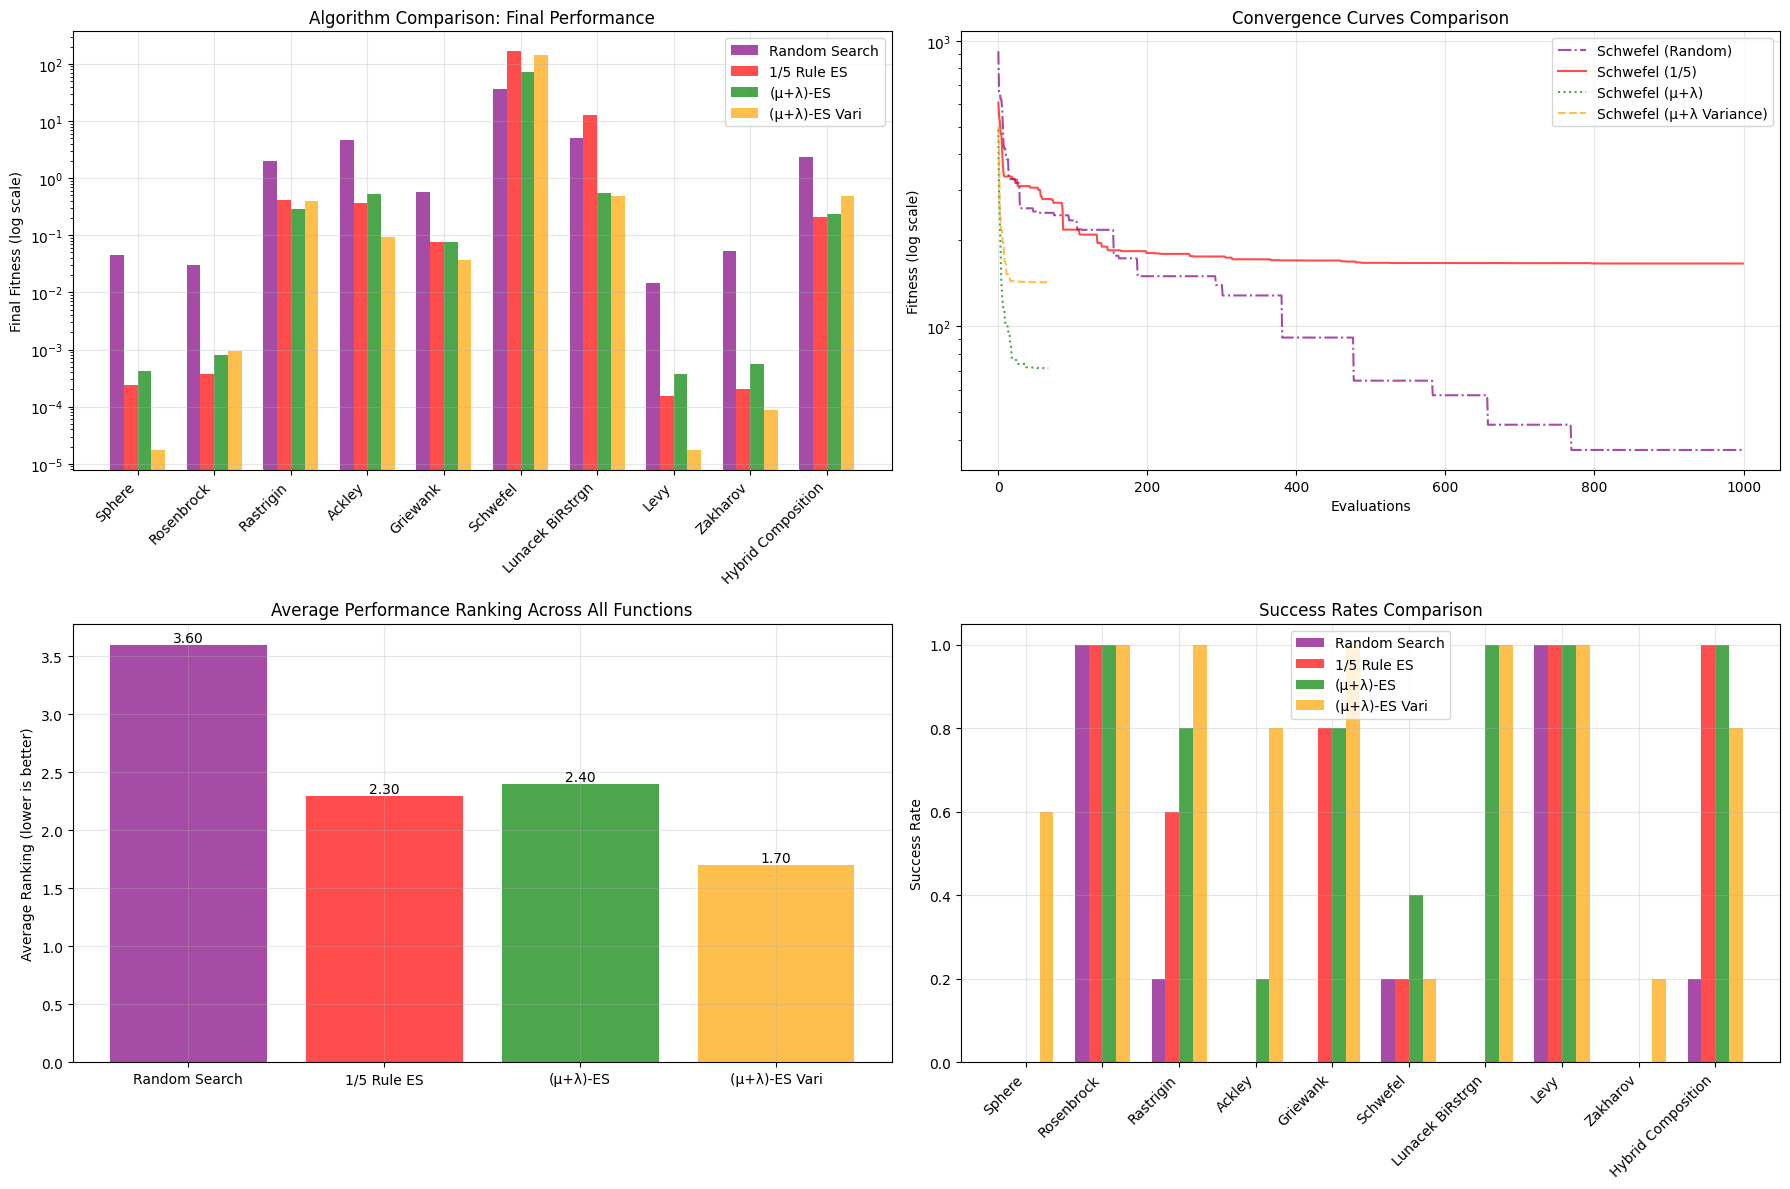

D = 5   Evolution Strategies and Random Search Algorithm Comparison
Random Search vs (1+1)-ES with 1/5 Rule vs (μ+λ)-ES with 1/5 Rule vs (μ+λ)-ES with Variance Adaptation
Evaluating Sphere (range: [-5.12, 5.12])...
  Run 1: Random = 1.514386e+00, 1/5 Rule = 8.399832e-05, (μ+λ)-ES = 1.237032e-03, (μ+λ)-ES Vari = 9.365593e-07
  Run 2: Random = 1.387204e+00, 1/5 Rule = 1.914507e-04, (μ+λ)-ES = 1.781195e-03, (μ+λ)-ES Vari = 1.148011e-06
  Run 3: Random = 1.620155e+00, 1/5 Rule = 7.069923e-05, (μ+λ)-ES = 1.328164e-03, (μ+λ)-ES Vari = 7.962536e-07
  Run 4: Random = 1.494211e+00, 1/5 Rule = 1.904716e-04, (μ+λ)-ES = 1.048058e-03, (μ+λ)-ES Vari = 9.790011e-07
  Run 5: Random = 3.017602e+00, 1/5 Rule = 2.287571e-04, (μ+λ)-ES = 4.777504e-04, (μ+λ)-ES Vari = 2.171429e-06
  Random Search: Mean = 1.806712e+00 ± 6.099e-01 std
  1/5 Rule ES:   Mean = 1.530754e-04 ± 6.349e-05 std
  (μ+λ)-ES:      Mean = 1.174440e-03 ± 4.236e-04 std
  (μ+λ)-ES Vari: Mean = 1.206251e-06 ± 4.955e-07 std
Evaluating Rosenbr

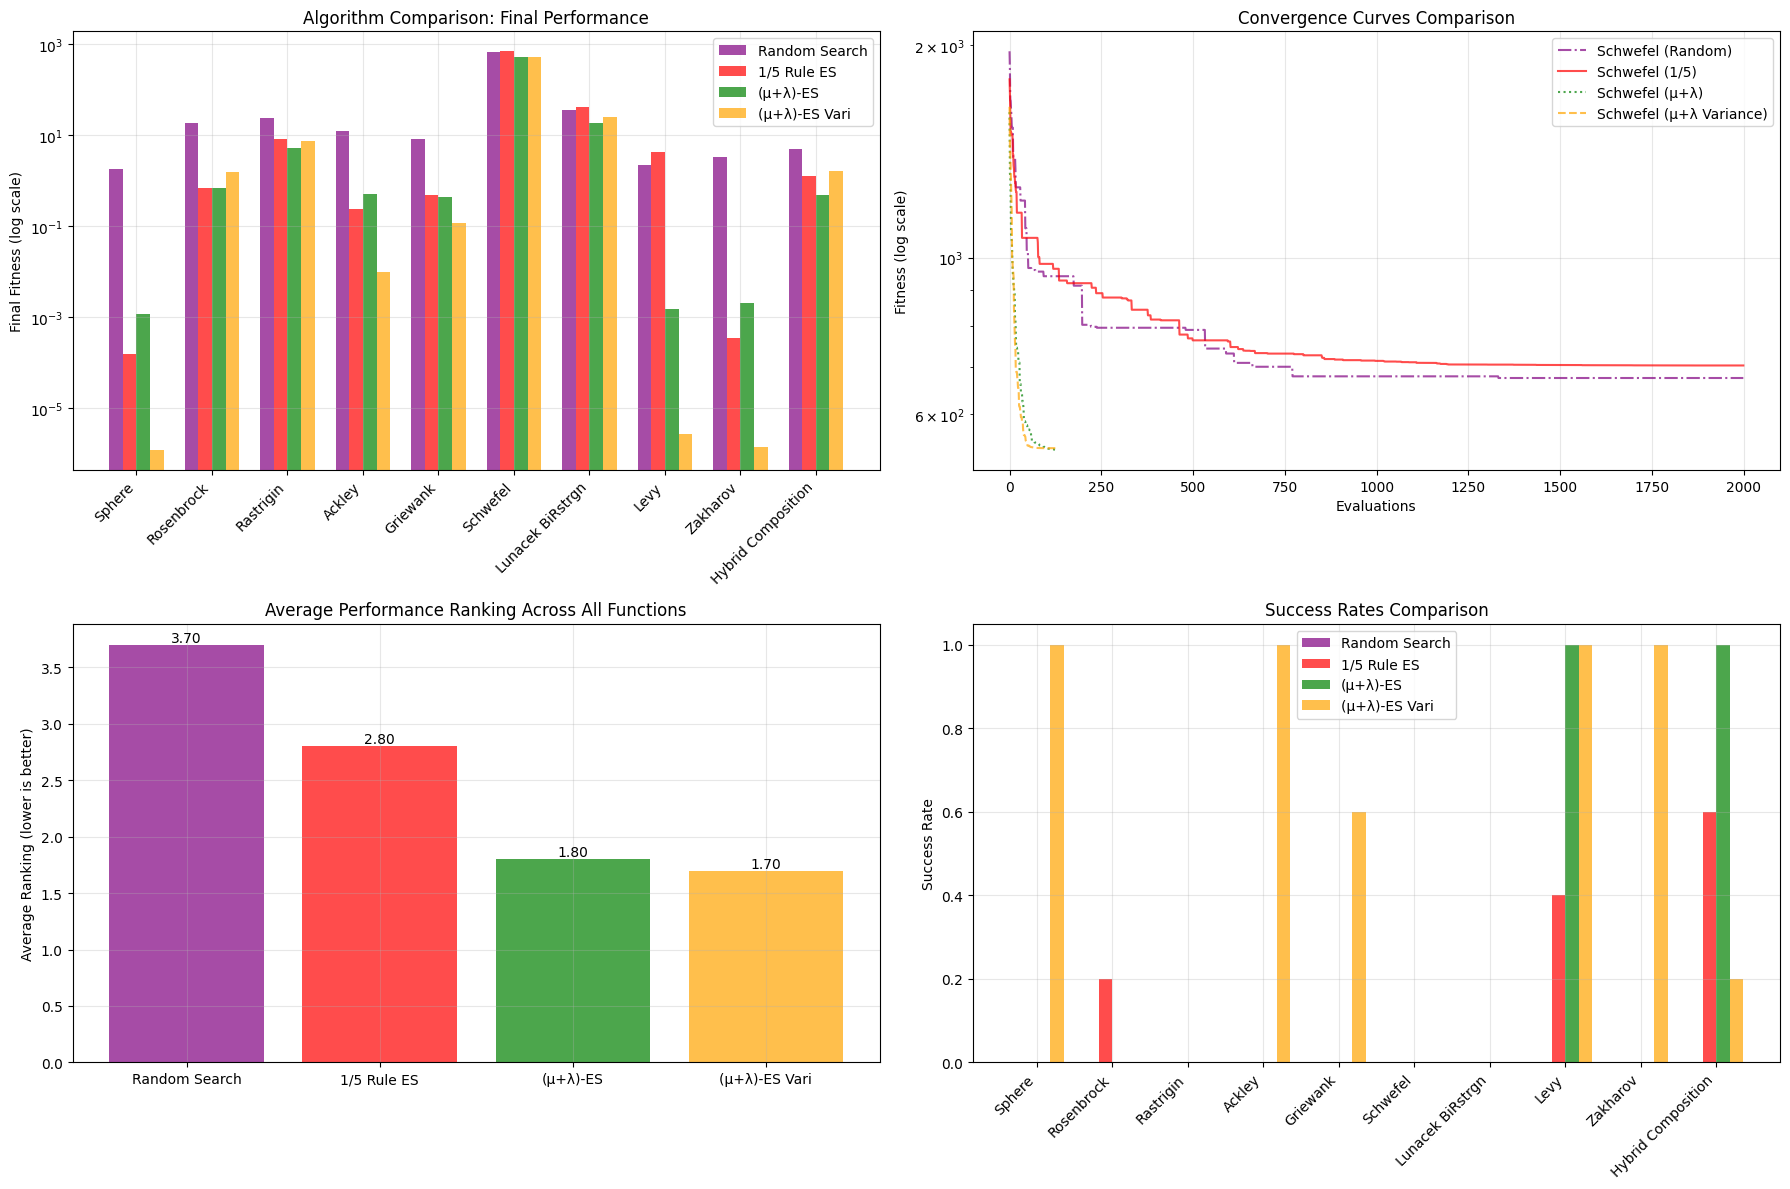

D = 10   Evolution Strategies and Random Search Algorithm Comparison
Random Search vs (1+1)-ES with 1/5 Rule vs (μ+λ)-ES with 1/5 Rule vs (μ+λ)-ES with Variance Adaptation
Evaluating Sphere (range: [-5.12, 5.12])...
  Run 1: Random = 1.681198e+01, 1/5 Rule = 9.508031e-06, (μ+λ)-ES = 7.372209e-04, (μ+λ)-ES Vari = 2.809103e-08
  Run 2: Random = 1.821902e+01, 1/5 Rule = 2.390426e-05, (μ+λ)-ES = 2.714568e-04, (μ+λ)-ES Vari = 5.718862e-09
  Run 3: Random = 1.230230e+01, 1/5 Rule = 3.182404e-05, (μ+λ)-ES = 2.819828e-04, (μ+λ)-ES Vari = 7.342656e-08
  Run 4: Random = 1.865303e+01, 1/5 Rule = 7.840245e-06, (μ+λ)-ES = 2.373614e-04, (μ+λ)-ES Vari = 1.892745e-07
  Run 5: Random = 2.181368e+01, 1/5 Rule = 2.130467e-05, (μ+λ)-ES = 2.886780e-04, (μ+λ)-ES Vari = 6.130367e-09
  Random Search: Mean = 1.756000e+01 ± 3.096e+00 std
  1/5 Rule ES:   Mean = 1.887625e-05 ± 9.037e-06 std
  (μ+λ)-ES:      Mean = 3.633400e-04 ± 1.878e-04 std
  (μ+λ)-ES Vari: Mean = 6.052826e-08 ± 6.893e-08 std
Evaluating Rosenb

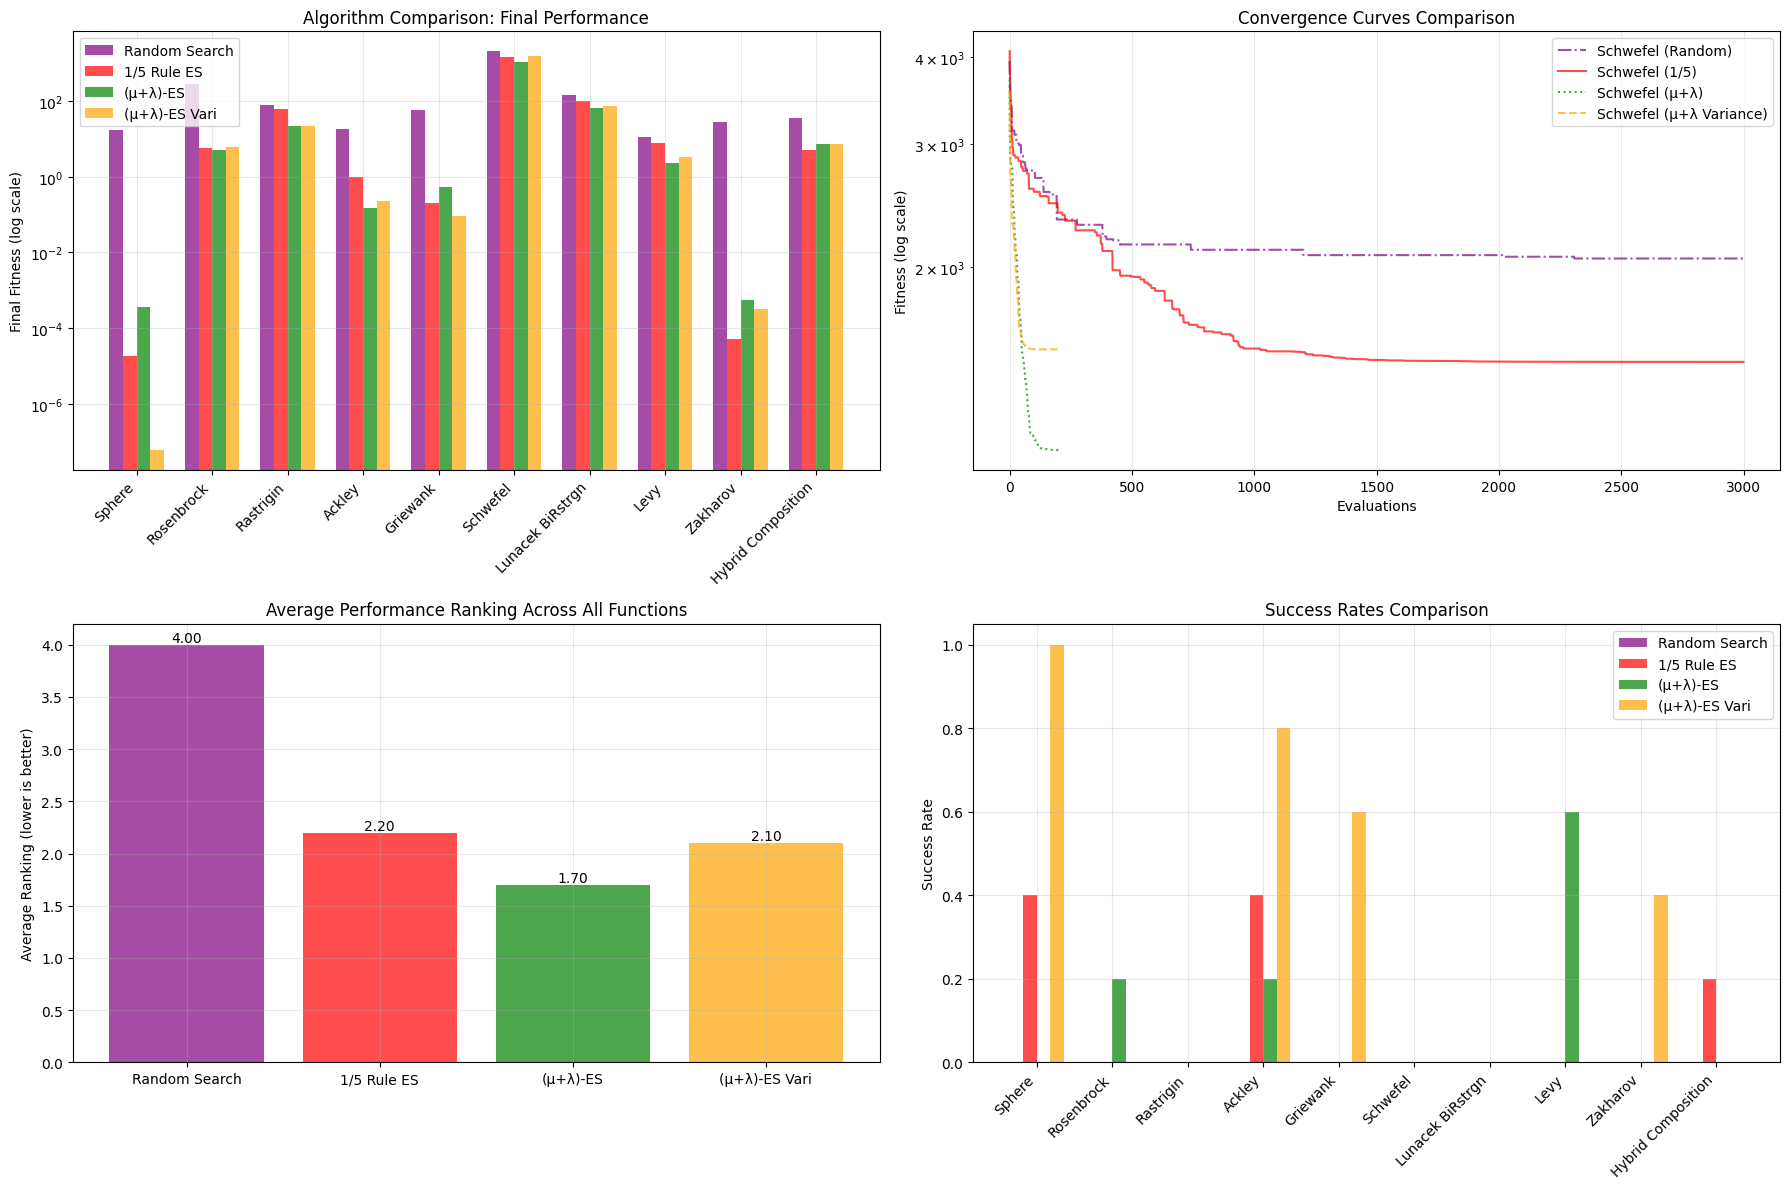

D = 20   Evolution Strategies and Random Search Algorithm Comparison
Random Search vs (1+1)-ES with 1/5 Rule vs (μ+λ)-ES with 1/5 Rule vs (μ+λ)-ES with Variance Adaptation
Evaluating Sphere (range: [-5.12, 5.12])...
  Run 1: Random = 5.856756e+01, 1/5 Rule = 4.410504e-08, (μ+λ)-ES = 3.066753e-06, (μ+λ)-ES Vari = 3.492851e-09
  Run 2: Random = 5.693327e+01, 1/5 Rule = 1.380209e-08, (μ+λ)-ES = 3.756945e-06, (μ+λ)-ES Vari = 6.589021e-08
  Run 3: Random = 6.075222e+01, 1/5 Rule = 3.041783e-08, (μ+λ)-ES = 1.972364e-06, (μ+λ)-ES Vari = 7.149206e-07
  Run 4: Random = 5.920915e+01, 1/5 Rule = 1.902655e-08, (μ+λ)-ES = 1.700574e-06, (μ+λ)-ES Vari = 2.033327e-07
  Run 5: Random = 6.601897e+01, 1/5 Rule = 2.593935e-08, (μ+λ)-ES = 9.432932e-06, (μ+λ)-ES Vari = 2.750329e-08
  Random Search: Mean = 6.029623e+01 ± 3.112e+00 std
  1/5 Rule ES:   Mean = 2.665817e-08 ± 1.042e-08 std
  (μ+λ)-ES:      Mean = 3.985914e-06 ± 2.823e-06 std
  (μ+λ)-ES Vari: Mean = 2.030279e-07 ± 2.651e-07 std
Evaluating Rosenb

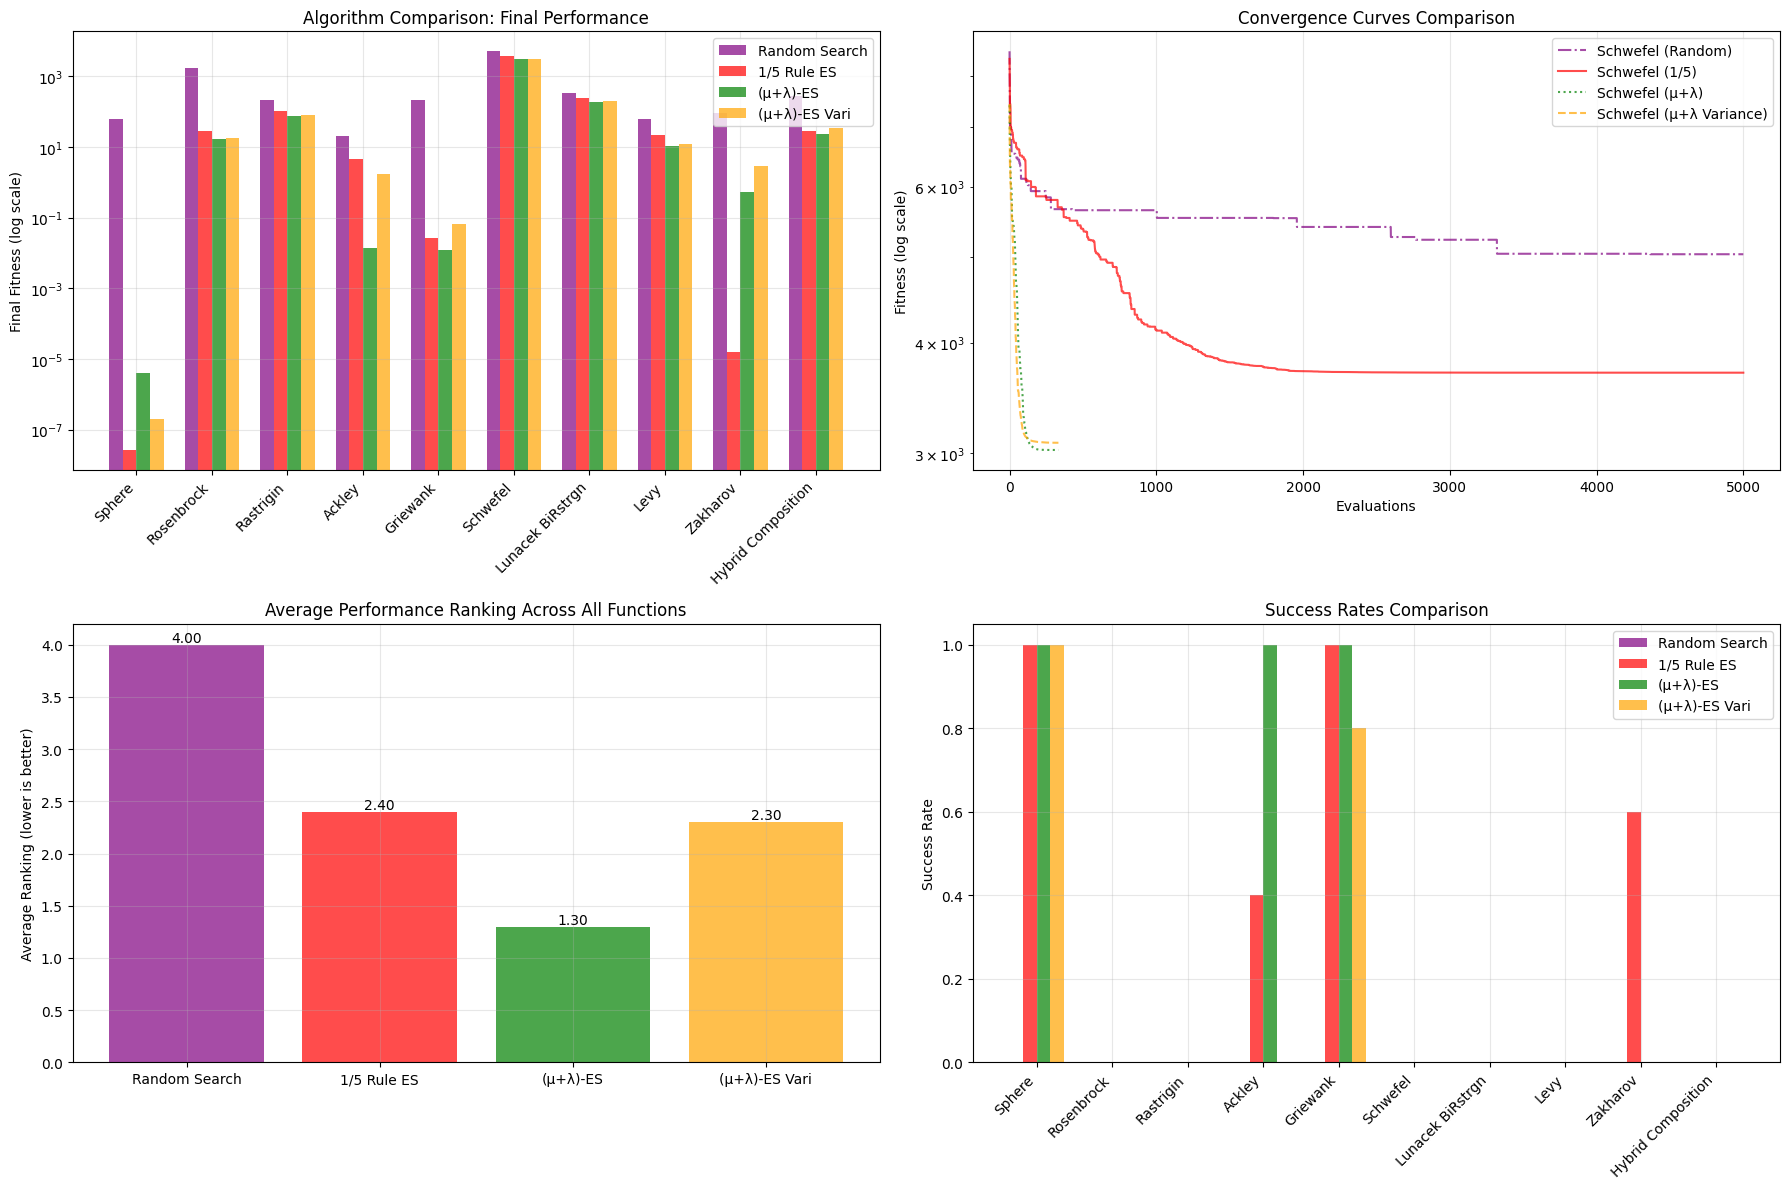

D = 50   Evolution Strategies and Random Search Algorithm Comparison
Random Search vs (1+1)-ES with 1/5 Rule vs (μ+λ)-ES with 1/5 Rule vs (μ+λ)-ES with Variance Adaptation
Evaluating Sphere (range: [-5.12, 5.12])...
  Run 1: Random = 2.643556e+02, 1/5 Rule = 6.402919e-09, (μ+λ)-ES = 2.283163e-07, (μ+λ)-ES Vari = 1.086080e-06
  Run 2: Random = 2.179361e+02, 1/5 Rule = 6.416188e-09, (μ+λ)-ES = 9.509458e-07, (μ+λ)-ES Vari = 8.949213e-07
  Run 3: Random = 2.406071e+02, 1/5 Rule = 7.827490e-09, (μ+λ)-ES = 3.110487e-07, (μ+λ)-ES Vari = 4.073172e-07
  Run 4: Random = 2.451566e+02, 1/5 Rule = 6.013945e-09, (μ+λ)-ES = 9.121873e-07, (μ+λ)-ES Vari = 8.893424e-01
  Run 5: Random = 2.517125e+02, 1/5 Rule = 6.492453e-09, (μ+λ)-ES = 5.437068e-07, (μ+λ)-ES Vari = 1.604890e-07
  Random Search: Mean = 2.439536e+02 ± 1.527e+01 std
  1/5 Rule ES:   Mean = 6.630599e-09 ± 6.212e-10 std
  (μ+λ)-ES:      Mean = 5.892409e-07 ± 2.983e-07 std
  (μ+λ)-ES Vari: Mean = 1.778690e-01 ± 3.557e-01 std
Evaluating Rosenb

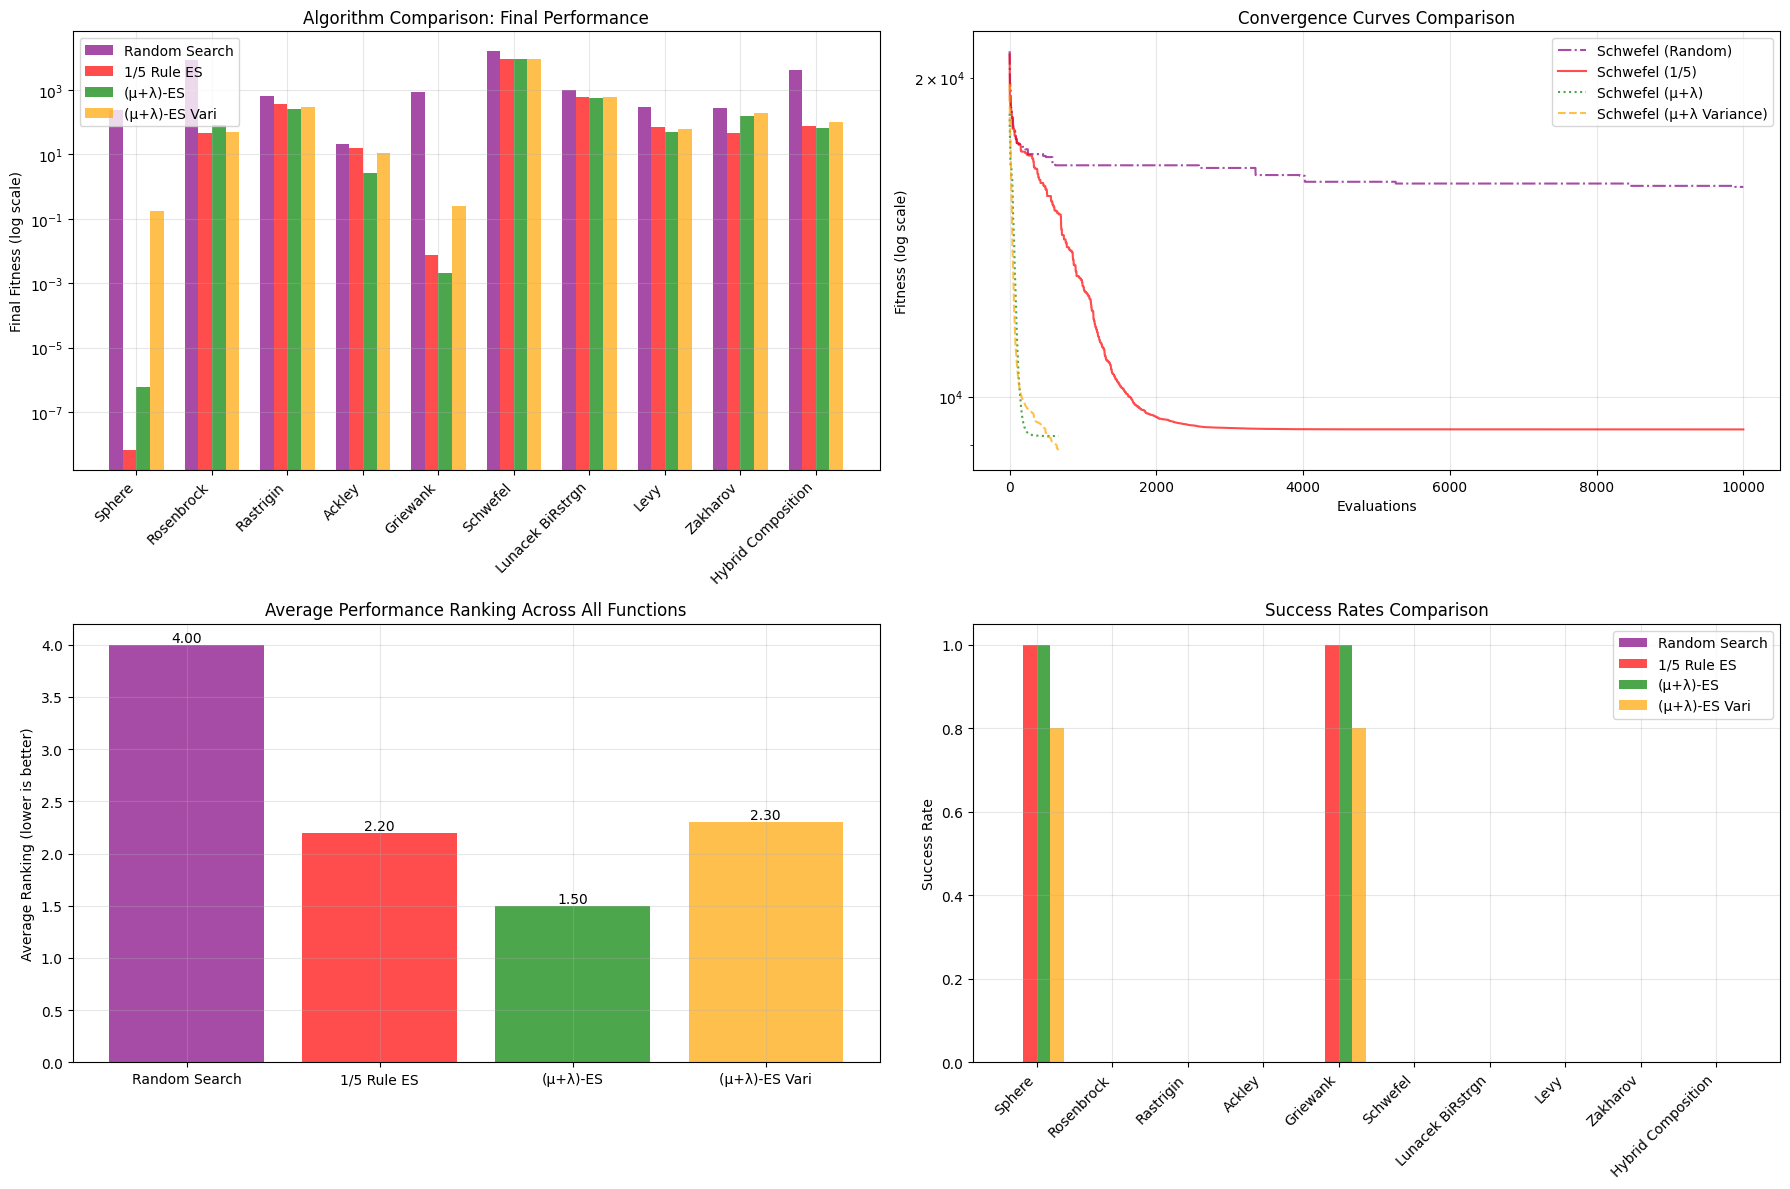

In [ ]:
def main(dim=30, max_evaluations=5000, runs=5):
    print(f"D = {dim}   Evolution Strategies and Random Search Algorithm Comparison")
    print("Random Search vs (1+1)-ES with 1/5 Rule vs (μ+λ)-ES with 1/5 Rule vs (μ+λ)-ES with Variance Adaptation")
    print("=" * 100)

    # Run evaluation
    # Updated call to evaluate_all_functions
    results_random, results_one_fifth, results_mu_plus_lambda, results_mu_plus_lambda_variance, functions = evaluate_all_functions(
        dim, max_evaluations, runs
    )

    # Display results
    # Updated call to print_comparison_table
    print_comparison_table(results_random, results_one_fifth, results_mu_plus_lambda, results_mu_plus_lambda_variance, functions, dim)

    # Generate plots
    # Updated call to plot_comparison_results
    plot_comparison_results(results_random, results_one_fifth, results_mu_plus_lambda, results_mu_plus_lambda_variance, functions)

if __name__ == "__main__":
    main(dim=2, max_evaluations=1000, runs=5)
    main(dim=5, max_evaluations=2000, runs=5)
    main(dim=10, max_evaluations=3000, runs=5)
    main(dim=20, max_evaluations=5000, runs=5)
    main(dim=50, max_evaluations=10000, runs=5)